# Eksperimen Delivery Time Estimation - Dika Ramadani

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
# Load dataset
df = pd.read_csv('../porter-delivery-time-estimation_raw/dataset.csv')

# Tampilkan informasi dasar
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (197428, 14)

First 5 Rows:
   market_id           created_at actual_delivery_time  \
0        1.0  2015-02-06 22:24:17  2015-02-06 23:27:16   
1        2.0  2015-02-10 21:49:25  2015-02-10 22:56:29   
2        3.0  2015-01-22 20:39:28  2015-01-22 21:09:09   
3        3.0  2015-02-03 21:21:45  2015-02-03 22:13:00   
4        3.0  2015-02-15 02:40:36  2015-02-15 03:20:26   

                           store_id store_primary_category  order_protocol  \
0  df263d996281d984952c07998dc54358               american             1.0   
1  f0ade77b43923b38237db569b016ba25                mexican             2.0   
2  f0ade77b43923b38237db569b016ba25                    NaN             1.0   
3  f0ade77b43923b38237db569b016ba25                    NaN             1.0   
4  f0ade77b43923b38237db569b016ba25                    NaN             1.0   

   total_items  subtotal  num_distinct_items  min_item_price  max_item_price  \
0            4      3441                   4             55

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Ringkasan Variabel Target (Durasi Pengiriman):
count    1.974210e+05
mean     2.908257e+03
std      1.922961e+04
min      1.010000e+02
25%      2.104000e+03
50%      2.660000e+03
75%      3.381000e+03
max      8.516859e+06
Name: delivery_duration_seconds, dtype: float64


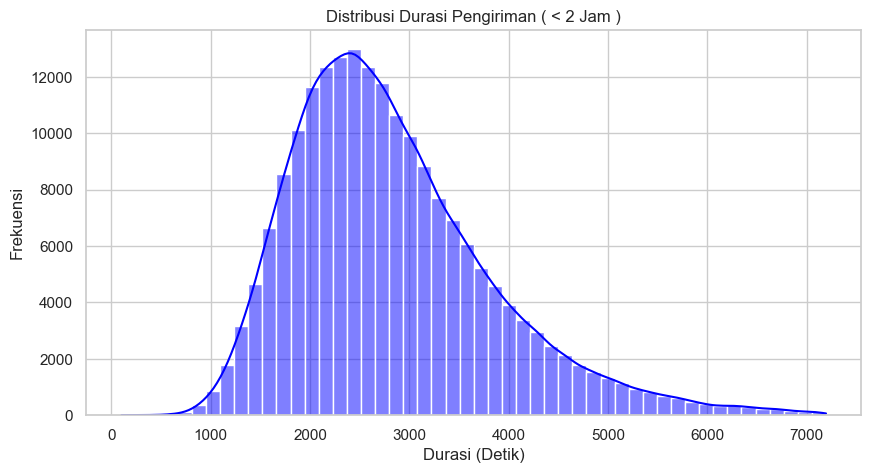

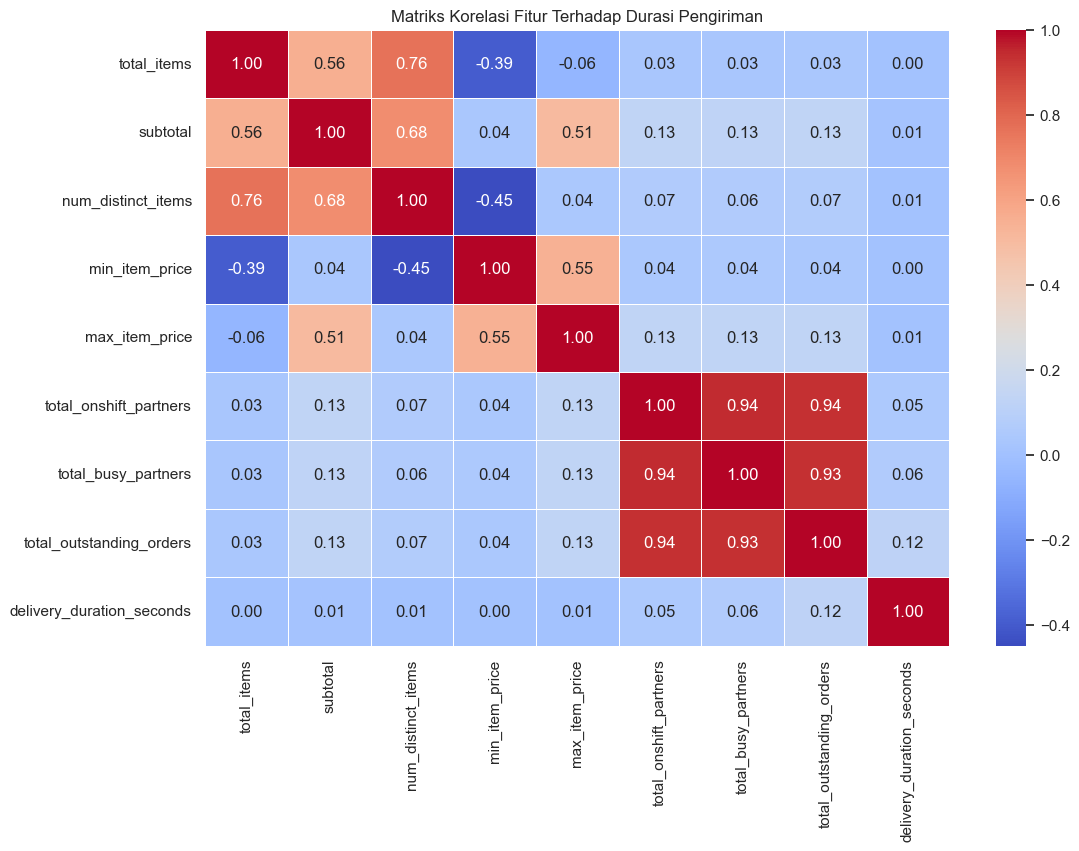

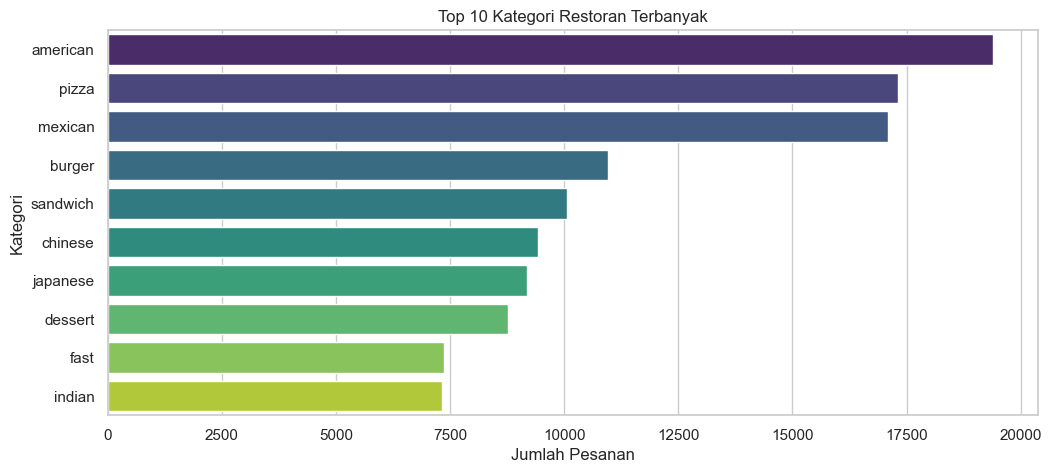

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../porter-delivery-time-estimation_raw/dataset.csv')

# Set style untuk visualisasi
sns.set_theme(style="whitegrid")

# 1. Membuat variabel target (Delivery Time dalam hitungan detik)
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

# Selisih waktu dikonversi ke total detik
df['delivery_duration_seconds'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds()

print("Ringkasan Variabel Target (Durasi Pengiriman):")
print(df['delivery_duration_seconds'].describe())

# 2. Visualisasi Distribusi Target (Membatasi data normal < 2 jam / 7200 detik untuk kejelasan grafik)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['delivery_duration_seconds'] < 7200]['delivery_duration_seconds'], bins=50, kde=True, color='blue')
plt.title('Distribusi Durasi Pengiriman ( < 2 Jam )')
plt.xlabel('Durasi (Detik)')
plt.ylabel('Frekuensi')
plt.show()

# 3. Memeriksa Korelasi antara Fitur Numerik dengan Target
numerical_cols = [
    'total_items', 'subtotal', 'num_distinct_items', 
    'min_item_price', 'max_item_price', 'total_onshift_partners', 
    'total_busy_partners', 'total_outstanding_orders', 'delivery_duration_seconds'
]

plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur Terhadap Durasi Pengiriman')
plt.show()

# 4. Melihat 10 Kategori Restoran Terpopuler
plt.figure(figsize=(12, 5))
top_categories = df['store_primary_category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 10 Kategori Restoran Terbanyak')
plt.xlabel('Jumlah Pesanan')
plt.ylabel('Kategori')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
# Membuat salinan dataframe untuk preprocessing
df_clean = df.copy()

print(f"Ukuran dataset awal: {df_clean.shape}")

# 1. Menangani Missing Values pada Target Variable
# Menghapus baris jika actual_delivery_time kosong karena target wajib ada
df_clean = df_clean.dropna(subset=['actual_delivery_time'])

# 2. Menghapus Nilai Anomali / Outliers Berdasarkan Logika Bisnis
# Menghapus data jika min_item_price bernilai negatif
df_clean = df_clean[df_clean['min_item_price'] >= 0]

# Menghapus nilai partner atau outstanding order yang negatif (jika ada)
df_clean = df_clean[(df_clean['total_onshift_partners'] >= 0) | (df_clean['total_onshift_partners'].isna())]
df_clean = df_clean[(df_clean['total_busy_partners'] >= 0) | (df_clean['total_busy_partners'].isna())]
df_clean = df_clean[(df_clean['total_outstanding_orders'] >= 0) | (df_clean['total_outstanding_orders'].isna())]

# Menangani outlier ekstrem pada durasi pengiriman (misal membatasi maksimal 3 jam atau 10800 detik)
# Serta memastikan durasi bernilai positif (> 0)
df_clean = df_clean[(df_clean['delivery_duration_seconds'] > 0) & (df_clean['delivery_duration_seconds'] <= 10800)]

# 3. Imputasi Missing Values pada Fitur Lainnya
# Kolom Kategorikal / Protokol: Diisi dengan nilai modus (nilai yang paling sering muncul)
df_clean['market_id'] = df_clean['market_id'].fillna(df_clean['market_id'].mode()[0])
df_clean['order_protocol'] = df_clean['order_protocol'].fillna(df_clean['order_protocol'].mode()[0])
df_clean['store_primary_category'] = df_clean['store_primary_category'].fillna('unknown')

# Kolom Numerikal (Partner & Order): Diisi dengan nilai median agar lebih aman dari pengaruh outlier
df_clean['total_onshift_partners'] = df_clean['total_onshift_partners'].fillna(df_clean['total_onshift_partners'].median())
df_clean['total_busy_partners'] = df_clean['total_busy_partners'].fillna(df_clean['total_busy_partners'].median())
df_clean['total_outstanding_orders'] = df_clean['total_outstanding_orders'].fillna(df_clean['total_outstanding_orders'].median())

# 4. Drop Fitur yang Tidak Digunakan oleh Model
# Kolom waktu asal di-drop karena informasinya sudah diekstrak menjadi delivery_duration_seconds
# store_id juga di-drop karena memiliki kardinalitas yang terlalu tinggi (terlalu banyak nilai unik)
columns_to_drop = ['created_at', 'actual_delivery_time', 'store_id']
df_clean = df_clean.drop(columns=columns_to_drop)

# 5. Encoding Data Kategorikal
# Mengambil 20 kategori store terbanyak untuk one-hot encoding agar kolom tidak terlalu bengkak, sisanya dikelompokkan ke 'other'
top_20_categories = df_clean['store_primary_category'].value_counts().head(20).index
df_clean['store_primary_category'] = df_clean['store_primary_category'].apply(lambda x: x if x in top_20_categories else 'other')

# Mengubah variabel kategorikal menjadi representasi numerik menggunakan One-Hot Encoding
df_clean = pd.get_dummies(df_clean, columns=['market_id', 'order_protocol', 'store_primary_category'], drop_first=True)

print(f"Ukuran dataset setelah preprocessing: {df_clean.shape}")
print(f"Jumlah missing values tersisa: {df_clean.isnull().sum().sum()}")

# 6. Menyimpan Data Hasil Preprocessing Berdasarkan Ketentuan Kriteria 1
import os
output_dir = 'porter-delivery-time-estimation_preprocessing'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'porter_delivery_preprocessed.csv')

df_clean.to_csv(output_path, index=False)
print(f"Dataset berhasil disimpan di: {output_path}")

Ukuran dataset awal: (197428, 15)
Ukuran dataset setelah preprocessing: (197189, 39)
Jumlah missing values tersisa: 0
Dataset berhasil disimpan di: porter-delivery-time-estimation_preprocessing/porter_delivery_preprocessed.csv
